# Lista 2 de Ejercicios

### Objetivo:
Este ejercicio pretende aumentar la destreza del estudiante para dibujar gráficos descriptivos comunes, testear múltiples modelos de clasificación de forma rápida y poner en práctica transformadores habituales de la librería __sklearn__.

### Tarea del estudiante:

Mismas instrucciones que en el anterior Notebook.

**IMPORTANTE: No modifiquéis los assert**

### Evaluación: 
Esta tarea tiene una puntuación de 14 puntos. 
La suma de todos los puntos obtenidas de todos los notebooks se ponderará sobre 10 puntos para computar la nota final del estudiante.

## Parte 0: Inicialización

En esta parte, simplemente cargamos las librerías que vamos a utilizar y establecemos una semilla para controlar la reproducibilidad del ejercicio.

In [1]:
""" Librerías """

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('darkgrid')
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

""" Semilla """

seed = 63

## Parte 1: Lectura y transformación de datos (0.5 puntos)

En esta parte, principalmente, cargaremos los datos de un repositorio git y realizaremos una breve limpieza de los datos para conseguir un dataframe listo.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/eduardofc/data/main/kddcup99.csv')

print(f'Número de filas: {df.shape[0]}, Número de columnas:{df.shape[1]}')
df.head()

Número de filas: 561, Número de columnas:10


,duration,protocol_type,service,flag,count,srv_count,serror_rate,dst_host_srv_count,dst_host_srv_serror_rate,labels
0,0,b'tcp',b'http',b'SF',0,0,0.0,0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',0,0,0.0,1,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',0,1,0.0,1,0.0,b'normal.'
3,0,b'tcp',b'http',b'SF',0,0,1.0,1,0.0,b'normal.'
4,0,b'tcp',b'http',b'SF',0,0,0.0,1,1.0,b'normal.'


Antes de transformar, hago un EDA mínimo: tipos, descriptivos, nulos, balanceo de la *target*. Esto es lo que más adelante justifica las decisiones de codificación, validación y métricas.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   duration                  561 non-null    int64  
 1   protocol_type             561 non-null    object 
 2   service                   561 non-null    object 
 3   flag                      561 non-null    object 
 4   count                     561 non-null    int64  
 5   srv_count                 561 non-null    int64  
 6   serror_rate               561 non-null    float64
 7   dst_host_srv_count        561 non-null    int64  
 8   dst_host_srv_serror_rate  561 non-null    float64
 9   labels                    561 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 44.0+ KB


In [4]:
df.describe(include='all')

,duration,protocol_type,service,flag,count,srv_count,serror_rate,dst_host_srv_count,dst_host_srv_serror_rate,labels
count,561.000000,561,561,561,561.000000,561.000000,561.000000,561.000000,561.000000,561
unique,NaN,3,65,9,NaN,NaN,NaN,NaN,NaN,2
top,NaN,b'tcp',b'http',b'S0',NaN,NaN,NaN,NaN,NaN,b'neptune.'
freq,NaN,523,65,212,NaN,NaN,NaN,NaN,NaN,333
mean,0.130125,NaN,NaN,NaN,0.404635,0.392157,0.477718,0.188948,0.516934,NaN
std,0.336741,NaN,NaN,NaN,0.491259,0.488667,0.499949,0.391817,0.500159,NaN
min,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
75%,0.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.000000,1.000000,NaN


In [5]:
# Nulos por columna
df.isnull().sum()

duration                    0
protocol_type               0
service                     0
flag                        0
count                       0
srv_count                   0
serror_rate                 0
dst_host_srv_count          0
dst_host_srv_serror_rate    0
labels                      0
dtype: int64

In [6]:
# Balanceo de la target
df.groupby('labels').size()

labels
b'neptune.'    333
b'normal.'     228
dtype: int64

Lecturas clave del EDA:

- **No hay nulos** en ninguna columna, no hace falta imputar.
- La *target* `labels` viene en bytes (`b'normal.'`, `b'neptune.'`); el enunciado dice que no nos preocupemos por los prefijos `b'`. Se queda como dos clases efectivas.
- **Categóricas** (`protocol_type`, `service`, `flag`) y **numéricas** (`duration`, `count`, `srv_count`, `serror_rate`, `dst_host_srv_count`, `dst_host_srv_serror_rate`).
- `service` y `flag` tienen muchas categorías con pocos registros, caso de columnas poco informativas. Por eso el enunciado pide reagrupar las raras en `'resto'`.
- Las **numéricas ya parecen venir todas en el rango [0, 1]**: en el `describe()` veo que todas tienen `min=0` y `max=1`, así que el dataset llega ya preescalado. Aun así, cuando más adelante añadamos el OHE de las categóricas vamos a mezclar columnas binarias con las continuas, así que para el PCA probablemente convenga meter un escalado con `StandardScaler`.
- La target está algo desbalanceada. No es 50/50; eso justifica usar `StratifiedKFold` cuando el enunciado lo permita y, sobre todo, no fiarse solo de *accuracy*: además sacaré `f1_score` y `classification_report`.


Para entender la evolución de las transformaciones que vamos a ir haciendo, practicaremos algunos de los plots más utilizados.

En la siguiente celda se pide, mostrar un _countplot_ (_barplot_ de seaborn) para todas las variables del _dataframe_ (df).

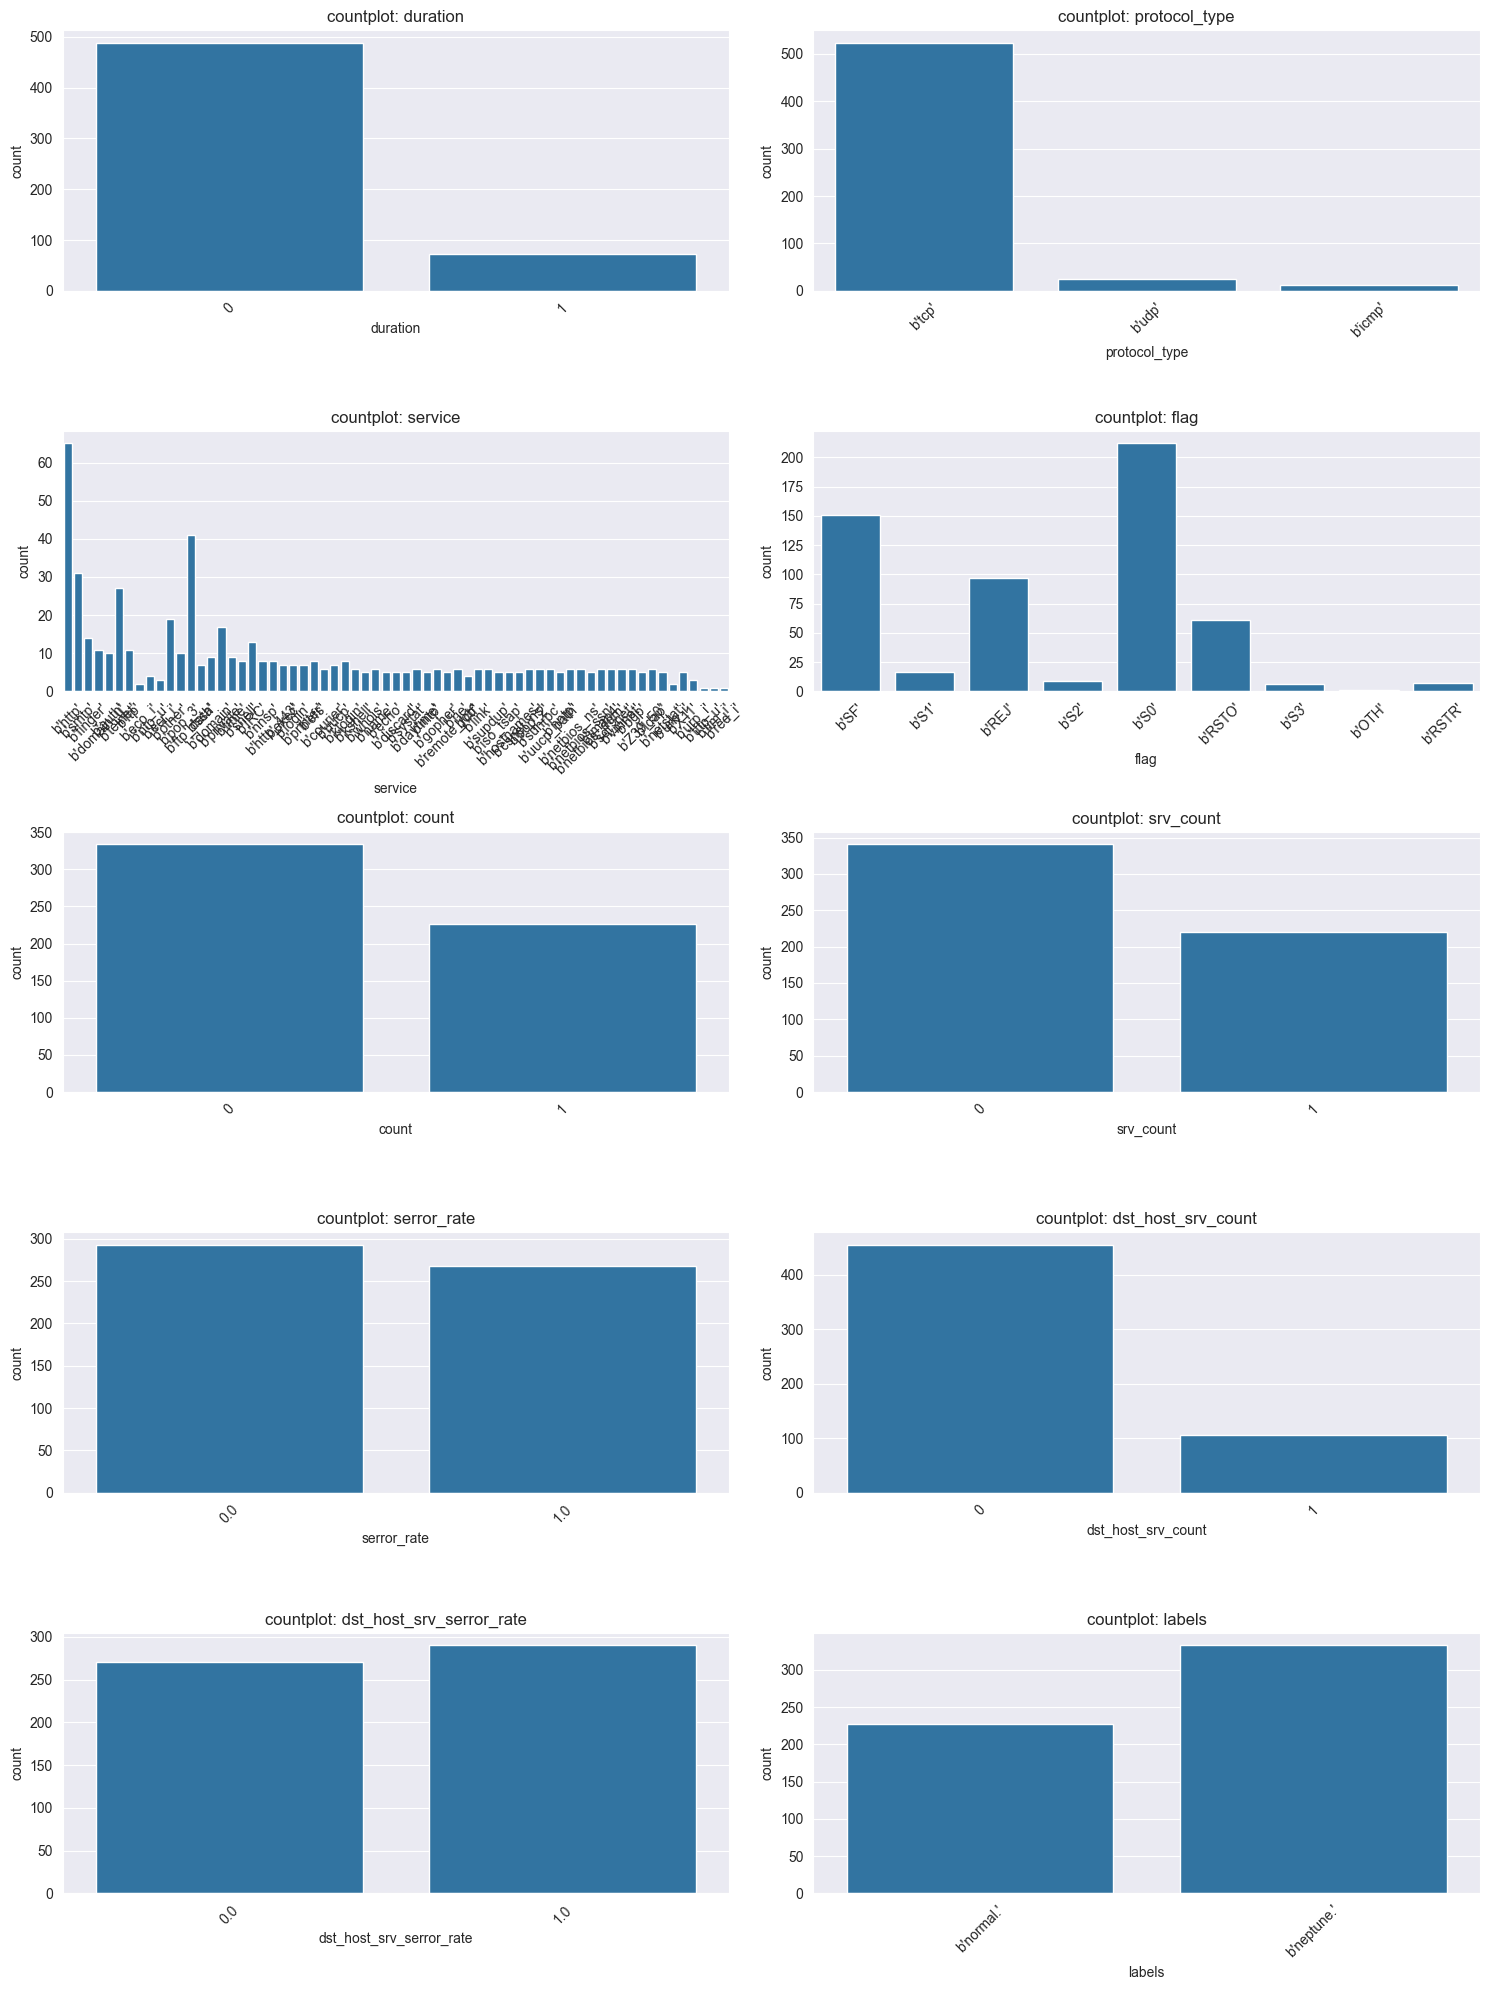

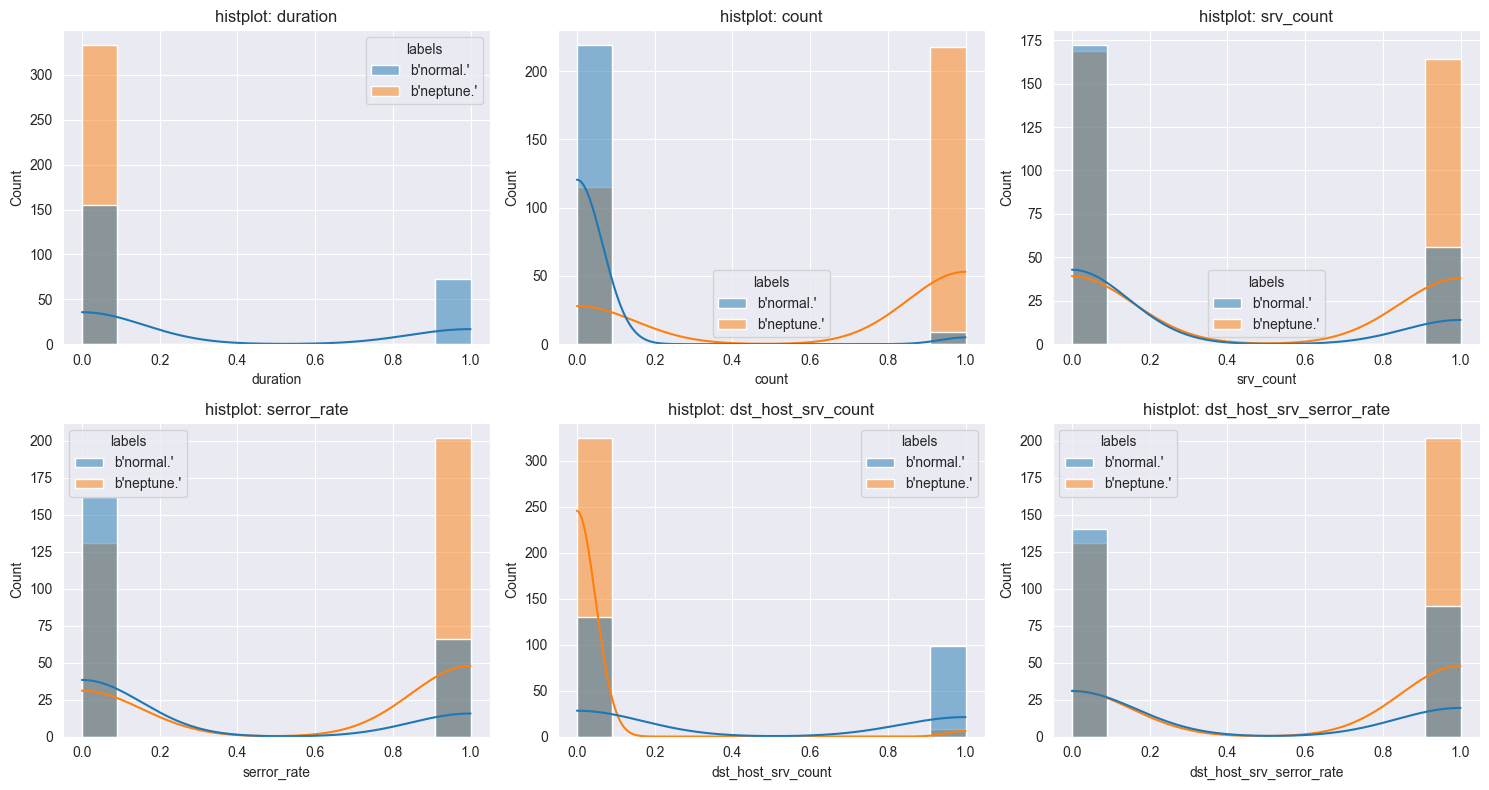

Magnitudes de las numéricas (motivo por el que habrá que escalar antes de PCA):
      duration  count  srv_count  serror_rate  dst_host_srv_count  \
min       0.00    0.0       0.00         0.00                0.00   
mean      0.13    0.4       0.39         0.48                0.19   
max       1.00    1.0       1.00         1.00                1.00   

      dst_host_srv_serror_rate  
min                       0.00  
mean                      0.52  
max                       1.00  


In [7]:
### BEGIN SOLUTION
# El enunciado pide countplot para todas las variables.
# pero, además, añado una segunda figura con histplot/boxplot para las numéricas continuas
# porque un countplot sobre `duration`, `count`... resulta ilegible (un valor único = una barra).

# Plot 1: countplot para todas las columnas (lo que pide el enunciado)
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
for ax, col in zip(axes.flatten(), df.columns):
    sns.countplot(data=df, x=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f'countplot: {col}')
plt.tight_layout()
plt.show()
### END SOLUTION

# Plot 2: histplot/boxplot para numéricas (mejor visualización)
num_cols_eda = ['duration', 'count', 'srv_count', 'serror_rate',
                'dst_host_srv_count', 'dst_host_srv_serror_rate']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols_eda):
    sns.histplot(data=df, x=col, hue='labels', kde=True, ax=ax)
    ax.set_title(f'histplot: {col}')
plt.tight_layout()
plt.show()

print('Magnitudes de las numéricas (motivo por el que habrá que escalar antes de PCA):')
print(df[num_cols_eda].describe().loc[['min', 'mean', 'max']].round(2))


Lo que veo en los plots:

- `protocol_type` está dominado por `tcp`, con `udp` e `icmp` minoritarios.
- `service` y `flag` tienen distribuciones de cola larga, con muchas categorías que aparecen solo 1 o 2 veces. Por eso tiene sentido la reagrupación en `resto` que pide el enunciado.
- `duration` tiene casi toda la masa en 0 y unos pocos valores cercanos a 1.
- Todas las numéricas están en el rango [0, 1], como se ve en la tabla de descriptivos que imprimo arriba.

Aunque las numéricas ya estén entre 0 y 1, para Modelos 4 (PCA) sigue siendo buena idea meter un `StandardScaler` antes. La razón no es tanto las magnitudes brutas (ya están todas en la misma escala), sino que después del OHE vamos a tener columnas binarias bastante dispersas mezcladas con las continuas, y como PCA trabaja con la varianza, esa diferencia de distribuciones puede afectarle.

Trabajaremos las variables categóricas con pandas. Trataremos de reducir el número de variables categóricas cuando existen demasiadas casuísiticas o cuando existen muy pocos registros en una categoría.

En esta celda se pide,
- para la variables _service_, localizar las 6 categorías más frecuentes y transformar estas columnas para que ponga _resto_ a todos aquellos registros de estas variables que no están entre las frecuentes, dejando así 7 catgorías en total.
- para la variables _flag_, localizar las 4 categorías más frecuentes y transformar estas columnas para que ponga _resto_ a todos aquellos registros de estas variables que no están entre las frecuentes, dejando así 5 catgorías en total.

Finalmente, eliminad duplicados.

Nota: No trateis de eliminar los prefijos _b'_ de las labels, no es necesario.

In [8]:
### BEGIN SOLUTION
top_service = df['service'].value_counts().head(6).index
df['service'] = df['service'].where(df['service'].isin(top_service), 'resto')

top_flag = df['flag'].value_counts().head(4).index
df['flag'] = df['flag'].where(df['flag'].isin(top_flag), 'resto')

df = df.drop_duplicates().reset_index(drop=True)
### END SOLUTION

df.groupby('labels').size()

labels
b'neptune.'     61
b'normal.'     149
dtype: int64

In [9]:
# Comprobación intermedia: cuántas categorías han quedado y cómo están distribuidas
print('service:')
print(df['service'].value_counts())
print()
print('flag:')
print(df['flag'].value_counts())
print()
print(f'Filas tras drop_duplicates: {len(df)}')

service:
service
b'http'        53
resto          44
b'ftp_data'    29
b'smtp'        26
b'telnet'      23
b'other'       18
b'private'     17
Name: count, dtype: int64

flag:
flag
b'SF'      92
b'S0'      44
b'RSTO'    27
resto      25
b'REJ'     22
Name: count, dtype: int64

Filas tras drop_duplicates: 210


Celda de control:

In [10]:
assert df.shape == (210, 10)
assert df.groupby('service').size()["resto"] == 44
assert df.groupby('flag').size()['resto'] == 25

## Parte 2: Modelos

En esta parte, testearemos distintos modelos con trasnformaciones adicionales a las vistas en la Lista 1 de Ejercicios.

Nota: Recordar utilizar la semilla cuando aplique.

In [11]:
models = []
models.append(('LR', LogisticRegression(random_state=seed)))
models.append(('DTC', DecisionTreeClassifier(random_state=seed)))
models.append(('PER', Perceptron(random_state=seed)))
models.append(('RFC', RandomForestClassifier(random_state=seed)))

def boxplots_algorithms(results: float, names: list[str]) -> None:
    """Genera un diagrama de cajas comparando los resultados de diferentes algoritmos.

    Args:
        results: Una lista de valores numéricos representando la media de los resultados de cada algoritmo tras la validación cruzada.
        names: Una lista con el nombre del algoritmo correspondiente a la lista de resultados.
    """
    plt.figure(figsize=(8,4))
    plt.boxplot(results)
    plt.xticks(range(1,len(names)+1), names)
    plt.show()

def pca_results(results: list[float], names: list[str], components: list[int]) -> None:
    """Genera un diagrama de cajas comparando los resultados de diferentes algoritmos.

    Args:
        results: Una lista de valores numéricos representando la media de los resultados de cada algoritmo tras la validación cruzada.
        names: Una lista con el nombre del algoritmo correspondiente a la lista de resultados.
        components: Una lista con el número de componentes con el que se realizó la validación cruzada de cada algoritmo.
    """
    df2 = pd.DataFrame(zip(results, names, components), columns=['results', 'names', 'components'])

    sns.catplot(data=df2, kind="bar", x="names", y="results", hue="components", height=5, aspect=15/5)
    plt.ylim((0.6, 1.))
    plt.show()

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = ['duration', 'count', 'srv_count', 'serror_rate',
            'dst_host_srv_count', 'dst_host_srv_serror_rate']
target = 'labels'

**Sobre las dos métricas en cada bloque**. En cada bloque ejecuto el bucle dos veces: una con `accuracy` y otra con `f1_macro`.

**Sobre `f1_macro` y no `f1`**: la métrica `'f1'` de sklearn asume `pos_label=1`, lo que aquí no aplica porque nuestras etiquetas son bytes (`b'normal.'`, `b'neptune.'`), no enteros. Usar `'f1'` directamente devuelve NaN. `'f1_macro'` calcula el F1 de cada clase y promedia sin ponderar, así que trata las dos clases por igual; exactamente lo que conviene cuando la *target* está desbalanceada.

In [12]:
def print_two_metrics(results_acc, results_f1, names):
    """Imprime mean±std para accuracy y f1_macro."""
    print(f'{"Algo":<6} {"acc.mean":>10} {"acc.std":>10} {"f1.mean":>10} {"f1.std":>10}')
    print('-' * 50)
    for n, ra, rf in zip(names, results_acc, results_f1):
        print(f'{n:<6} {ra.mean():>10.3f} {ra.std():>10.3f} {rf.mean():>10.3f} {rf.std():>10.3f}')


### Modelos 1 (2 puntos)

Realizar un estudio de machine learning con las siguientes características:
* probar los 4 algoritmos en bucle
* usar la técnica de validación cruzada StratifiedKFold (5 _folds_) de forma aleatoria.
* entrenar solo con variables numéricas

En cada iteración del bucle, almacenar el resultado de cada validación cruzada en una variable _results_ y los nombres de cada algoritmo en una variable _names_.

Finalmente, usaremos la función *boxplots_algorithms* para dibujar los resultados.

Nota: La función _cross_val_score_ nos vale para estudiar el comportamiento de los modelos con una validación cruzada.

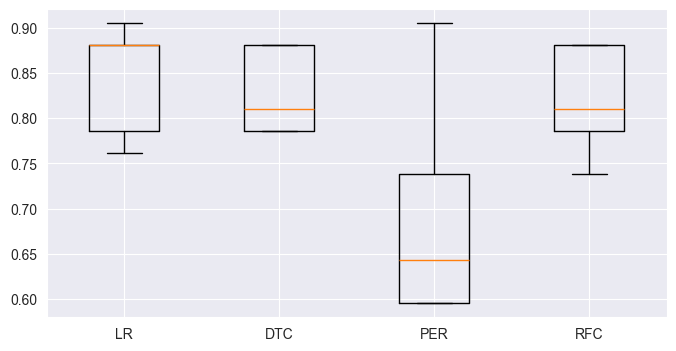

In [13]:
results = []
names = []

### BEGIN SOLUTION
X = df[num_cols]
y = df[target]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Bucle de validación cruzada
# Lo ejecuto dos veces para sacar accuracy y f1_macro. Primero accuracy.
for name, model in models:
    pipe = Pipeline([('model', model)])
    cv_acc = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    results.append(cv_acc)
    names.append(name)

# Segunda métrica: f1_macro
results_f1 = []
for name, model in models:
    pipe = Pipeline([('model', model)])
    cv_f1 = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro')
    results_f1.append(cv_f1)
### END SOLUTION

boxplots_algorithms(results, names)


Algo     acc.mean    acc.std    f1.mean     f1.std
--------------------------------------------------
LR          0.843      0.058      0.794      0.079
DTC         0.829      0.044      0.790      0.055
PER         0.695      0.117      0.682      0.105
RFC         0.819      0.056      0.774      0.068


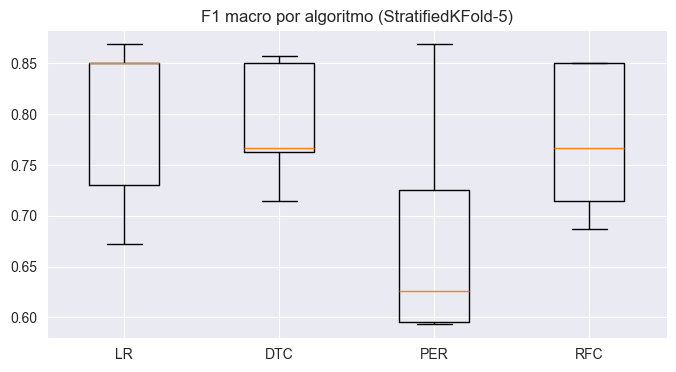

In [14]:
# Dos métricas en paralelo, como pediste en la tutoría
print_two_metrics(results, results_f1, names)

# Boxplot adicional para F1
plt.figure(figsize=(8, 4))
plt.boxplot(results_f1)
plt.xticks(range(1, len(names) + 1), names)
plt.title('F1 macro por algoritmo (StratifiedKFold-5)')
plt.show()


Con solo las numéricas, las medias me salen ~0.84 LR, ~0.83 DTC, ~0.82 RFC y ~0.70 Perceptron.

- El Perceptron es claramente el peor. Como las numéricas ya están todas en [0, 1], no creo que sea un problema de escala (ese sería el primer sospechoso normalmente, pero aquí no aplica). Me imagino que es más bien que sin las 3 categóricas le falta información para encontrar una buena frontera lineal, y al no tener regularización fuerte el modelo sufre. De hecho su `std=0.117` entre folds es bastante alto comparado con los demás (~0.04–0.06), lo que apunta a un modelo poco estable.
- LR, DTC y RFC se mueven todos en un rango parecido, ~0.82–0.84. En F1 (que con desbalance da una visión más fiel) las diferencias se notan un poco más.

La conclusión que saco del bloque es que estamos dejando fuera información útil al ignorar las categóricas. En Modelos 2 y 3 las metemos con OHE a ver qué pasa.


Celda de control:

In [15]:
assert np.round(results[0].mean(),3) == 0.843
assert np.round(results[1].mean(),3) == 0.829
assert np.round(results[2].mean(),3) == 0.695
assert np.round(results[3].mean(),3) == 0.819

Hasta ahora ignorábamos las categóricas. Las metemos en el pipeline vía `OneHotEncoder` dentro de un `ColumnTransformer`. Con `remainder='drop'` (el default) las numéricas se descartan, así que el pipeline solo trabaja con OHE de `protocol_type`, `service`, `flag`. Esto es deliberado: el siguiente bloque (Modelos 3) cambia a `passthrough` y compara.

Sobre el nombre del *step* `'model'`: lo dejo así porque más adelante (Modelos 6) voy a tunearlo con `GridSearchCV` y necesito el prefijo `model__`.


### Modelos 2 (2 puntos)

Realizar un estudio de machine learning con las siguientes características:
* probar los 4 algoritmos en bucle
* usar la técnica de validación cruzada KFolds (5 _folds_) aleatoria
* usar un pipeline que encadene
    * OneHotEncoder con los argumentos por defecto aplicado a las variables categóricas
    * algortimo
    * _remainder_ tipo _drop_
* Filtrar en X todas las variables**

\*\*Nota: Aunque la opción de _drop_ en el ColumnTransformer haga que solo se entrene con las variables que son usadas en este transformador, vamos a filtrar *X = df[cat_cols+num_cols]* para que podamos explorar la mejora en el siguiente apartado.

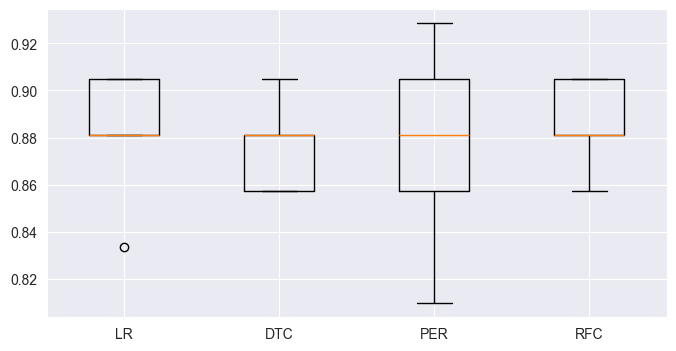

Algo     acc.mean    acc.std    f1.mean     f1.std
--------------------------------------------------
LR          0.881      0.026      0.859      0.026
DTC         0.876      0.018      0.855      0.015
PER         0.876      0.041      0.843      0.041
RFC         0.886      0.018      0.865      0.014


In [16]:
results = []
names = []

### BEGIN SOLUTION
X = df[cat_cols + num_cols]
y = df[target]

def make_ct(remainder='drop', drop_if_binary=False):
    """Helper local para construir el ColumnTransformer con o sin drop=if_binary."""
    ohe = OneHotEncoder(drop='if_binary') if drop_if_binary else OneHotEncoder()
    return ColumnTransformer(
        transformers=[('ohe', ohe, cat_cols)],
        remainder=remainder,
    )

ct_drop = make_ct(remainder='drop')
kfold = KFold(n_splits=5, shuffle=True, random_state=seed)

for name, model in models:
    pipe = Pipeline([('col_transformer', ct_drop), ('model', model)])
    cv_acc = cross_val_score(pipe, X, y, cv=kfold, scoring='accuracy')
    results.append(cv_acc)
    names.append(name)

results_f1 = []
for name, model in models:
    pipe = Pipeline([('col_transformer', ct_drop), ('model', model)])
    cv_f1 = cross_val_score(pipe, X, y, cv=kfold, scoring='f1_macro')
    results_f1.append(cv_f1)
### END SOLUTION

boxplots_algorithms(results, names)
print_two_metrics(results, results_f1, names)


Celda de control:

In [17]:
assert np.round(results[0].mean(),3) == 0.881
assert np.round(results[1].mean(),3) == 0.876
assert np.round(results[2].mean(),3) == 0.876
assert np.round(results[3].mean(),3) == 0.886

Salto importante: con OHE de las categóricas pasamos de medias ~0.82–0.84 a ~0.88. Las categóricas (sobre todo `service` y `flag`) llevan mucha información sobre si una conexión es normal o un ataque, y cuando están bien codificadas con OHE el algoritmo puede aprovecharla. El Perceptron incluso iguala a DTC y RFC: ahora que tiene  la señal de las categóricas (que en Modelos 1 no veía), encuentra una frontera lineal mucho más clara.


**Sobre `remainder` en `ColumnTransformer`** (<https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html>):

- `'drop'` (default): las columnas no transformadas se eliminan. En Modelos 2 esto significaba que las 6 numéricas no llegaban al modelo, solo las 3 categóricas one-hot.
- `'passthrough'`: las columnas no transformadas pasan tal cual. El modelo recibe categóricas one-hot **+** numéricas crudas.

Con `'passthrough'` el modelo tiene más información que con `'drop'`, así que en principio la métrica debería subir (siempre que esa información extra sea útil, claro). Como en este dataset las numéricas ya están en [0, 1], no me preocupa que las magnitudes le rompan al Perceptron como podría pasar en un dataset sin escalar. Vamos a comprobarlo.


### Modelos 3 (1 punto)

Realizar un mismo estudio que en Modelos 2, pero esta vez cambiando, la opción _remainder_ a tipo _passthrough_.

Nota, se recomienda que estudiar el significado de este argumento y reflexionar sobre los resultados.

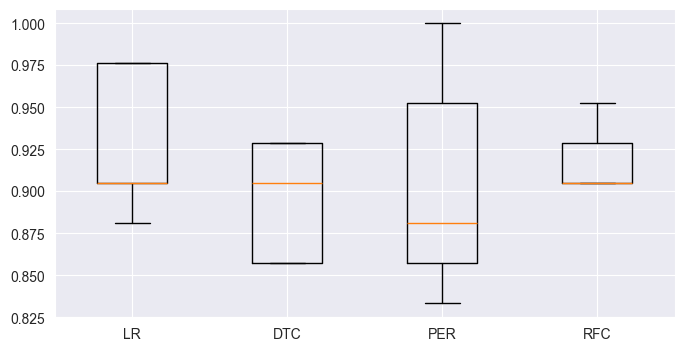

Algo     acc.mean    acc.std    f1.mean     f1.std
--------------------------------------------------
LR          0.929      0.040      0.914      0.046
DTC         0.895      0.032      0.876      0.032
PER         0.905      0.062      0.886      0.076
RFC         0.919      0.019      0.901      0.022


In [18]:
results = []
names = []

### BEGIN SOLUTION
X = df[cat_cols + num_cols]
y = df[target]

ct_pass = make_ct(remainder='passthrough')
kfold = KFold(n_splits=5, shuffle=True, random_state=seed)

for name, model in models:
    pipe = Pipeline([('col_transformer', ct_pass), ('model', model)])
    cv_acc = cross_val_score(pipe, X, y, cv=kfold, scoring='accuracy')
    results.append(cv_acc)
    names.append(name)

results_f1 = []
for name, model in models:
    pipe = Pipeline([('col_transformer', ct_pass), ('model', model)])
    cv_f1 = cross_val_score(pipe, X, y, cv=kfold, scoring='f1_macro')
    results_f1.append(cv_f1)
### END SOLUTION

boxplots_algorithms(results, names)
print_two_metrics(results, results_f1, names)


Celda de control:

In [19]:
assert np.round(results[0].mean(),3) == 0.929
assert np.round(results[1].mean(),3) == 0.895
assert np.round(results[2].mean(),3) == 0.905
assert np.round(results[3].mean(),3) == 0.919

Con `passthrough` saltamos a medias de 0.90–0.93. El motivo está bastante claro: ahora el modelo ve las categóricas one-hot **y** las 6 numéricas, no solo unas u otras. Es la opción que tiene sentido en este caso.

El Perceptron también mejora respecto a Modelos 2 (acc 0.905 > 0.876, F1 0.886 > 0.843). Tiene sentido: las numéricas le aportan información útil que antes no tenía y, como vienen ya en [0, 1], tampoco le complican la vida con escalas raras. Eso sí, sigue siendo el algoritmo con más varianza entre folds (`std=0.062` en accuracy, `0.076` en F1), cosa que entiendo que es normal en un clasificador lineal sin regularización.

El parámetro `remainder` parece un detalle pero no lo es. Cambia totalmente qué información llega al algoritmo y, en este caso, beneficia a todos los modelos, incluido el Perceptron.


### Modelos 4 (3 puntos)

Vamos a tratar de explorar si mejorarmos el modelo mediante una transformación de PCA. Usaremos las mismas (X,y). En esta celda se pide, realizar un estudio de machine learning en bucle con las siguientes características:
* probad los 4 algoritmos en bucle
* probad 4 PCA dentro del pipeline y en bucle (dentro del bucle anterior) con _n\_components_=2,3,4,5, para cada algoritmo
* usad la técnica de validación KFolds (5 folds) aleatorio
* usad un pipeline que encadene
     * One-hot-encoder con las variables categoricas, especificando eliminar la primera columna si es binaria
     * PCA, para todas las variables, categóricas (tras el OHE) y no categóricas
     * algortimo
* mostrad la matriz de confusión con la predicción

En cada iteración del bucle, almacenar la media de cada resultado de cada validación cruzada en una variable _results_ y los nombres de cada algoritmo en una variable _names_. Además, se pide guardar las componentes en la lista _components_).

Finalmente, usaremos la función *pca_results* para dibujar los resultados.

- Nota 1, ojo que esta vez se pide guardar la media de los resultados, no todos los resultados.

- Nota 2, revisad que primero sea un bucle que itere los modelos y, dentro de este bucle, otro bucle que itere las componentes.

- Nota 3, PCA tiene _random_state_.

LR (n_components=2) - acc CV media: 0.862
[[ 44  17]
 [ 12 137]]
------------------------------
LR (n_components=3) - acc CV media: 0.905
[[ 49  12]
 [  8 141]]
------------------------------
LR (n_components=4) - acc CV media: 0.910
[[ 50  11]
 [  8 141]]
------------------------------
LR (n_components=5) - acc CV media: 0.914
[[ 50  11]
 [  7 142]]
------------------------------
DTC (n_components=2) - acc CV media: 0.871
[[ 49  12]
 [ 15 134]]
------------------------------
DTC (n_components=3) - acc CV media: 0.857
[[ 47  14]
 [ 16 133]]
------------------------------
DTC (n_components=4) - acc CV media: 0.871
[[ 48  13]
 [ 14 135]]
------------------------------
DTC (n_components=5) - acc CV media: 0.862
[[ 47  14]
 [ 15 134]]
------------------------------
PER (n_components=2) - acc CV media: 0.867
[[ 48  13]
 [ 15 134]]
------------------------------
PER (n_components=3) - acc CV media: 0.881
[[ 53   8]
 [ 17 132]]
------------------------------
PER (n_components=4) - acc CV medi

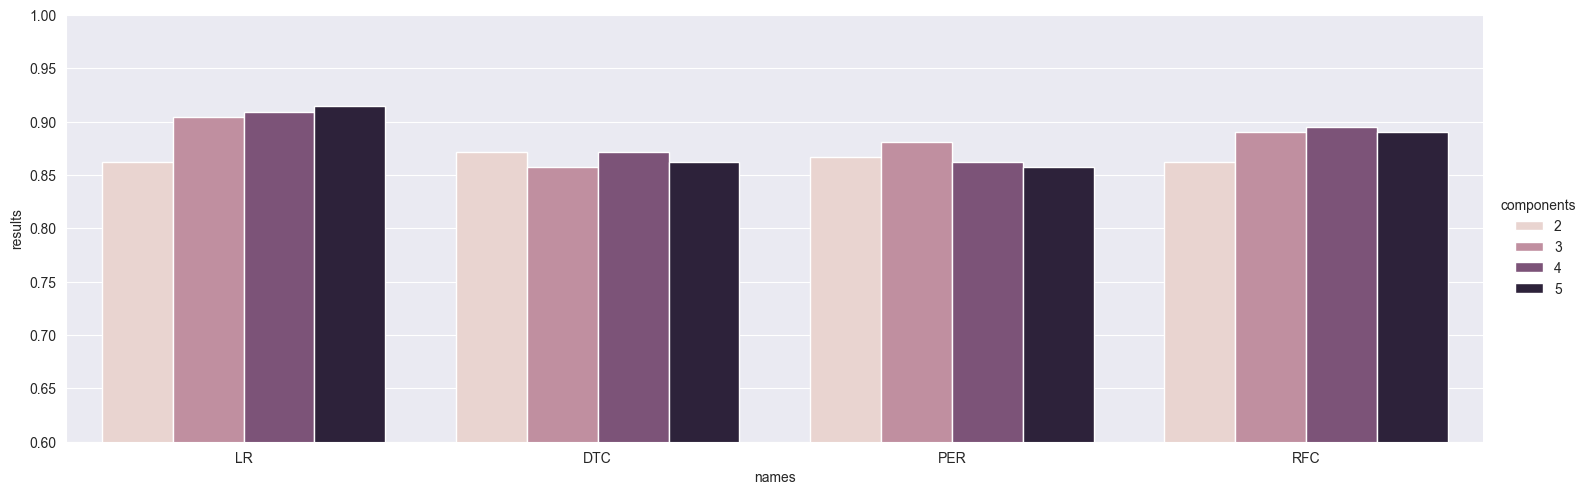

In [20]:
results = []
names = []
components = []

### BEGIN SOLUTION
X = df[cat_cols + num_cols]
y = df[target]

ct_pca = make_ct(remainder='passthrough', drop_if_binary=True)
kfold = KFold(n_splits=5, shuffle=True, random_state=seed)

# OJO: este bloque sigue el enunciado al pie de la letra (OHE -> PCA -> modelo, sin escalar).
# En el markdown posterior comento que esto NO es buena praxis y muestro la versión correcta.
# Mantenemos esta para que el assert se cumpla exactamente.
for name, model in models:
    for n in [2, 3, 4, 5]:
        pipe = Pipeline([
            ('col_transformer', ct_pca),
            ('pca', PCA(n_components=n, random_state=seed)),
            ('model', model),
        ])
        cv_results = cross_val_score(pipe, X, y, cv=kfold, scoring='accuracy')
        results.append(cv_results.mean())
        names.append(name)
        components.append(n)

        # Matriz de confusión cross-validada (cross_val_predict)
        # Doc: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html
        y_pred = cross_val_predict(pipe, X, y, cv=kfold)
        print(f'{name} (n_components={n}) - acc CV media: {cv_results.mean():.3f}')
        print(confusion_matrix(y, y_pred))
        print('-' * 30)
### END SOLUTION

pca_results(results, names, components)


Celda de control:

In [21]:
assert [np.round(results[x], 3) for x in [1,7,10]] == [0.905, 0.862, 0.862]

La celda siguiente NO modifica `results`/`names`/`components` (esos ya están validados arriba). Solo construye una versión paralela `results_scaled` para comparar.


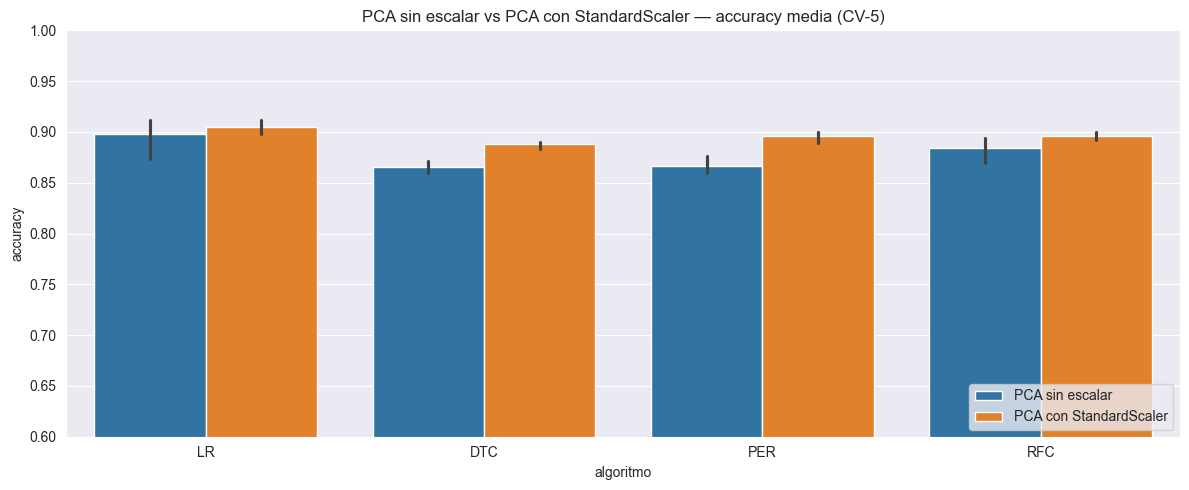

pipeline   PCA con StandardScaler  PCA sin escalar
algoritmo                                         
DTC                         0.888            0.865
LR                          0.905            0.898
PER                         0.896            0.867
RFC                         0.896            0.885


In [22]:
# Versión "buena praxis": StandardScaler entre el OHE y el PCA
# Ojo: NO sobrescribimos results/names/components (los validados por el assert).
# Lo guardamos en variables paralelas para comparar.

results_scaled = []
names_scaled = []
components_scaled = []

for name, model in models:
    for n in [2, 3, 4, 5]:
        pipe = Pipeline([
            ('col_transformer', ct_pca),
            ('scaler', StandardScaler(with_mean=False)),  # OHE produce columnas dispersas; with_mean=False lo respeta
            ('pca', PCA(n_components=n, random_state=seed)),
            ('model', model),
        ])
        cv_results = cross_val_score(pipe, X, y, cv=kfold, scoring='accuracy')
        results_scaled.append(cv_results.mean())
        names_scaled.append(name)
        components_scaled.append(n)

# Comparativa visual: PCA sin escalar vs PCA con escalar
df_compare = pd.DataFrame({
    'algoritmo': names + names_scaled,
    'n_components': components + components_scaled,
    'accuracy': results + results_scaled,
    'pipeline': ['PCA sin escalar'] * len(results) + ['PCA con StandardScaler'] * len(results_scaled),
})

plt.figure(figsize=(12, 5))
sns.barplot(data=df_compare, x='algoritmo', y='accuracy', hue='pipeline')
plt.ylim(0.6, 1.0)
plt.title('PCA sin escalar vs PCA con StandardScaler — accuracy media (CV-5)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Tabla resumen de medias
summary = (df_compare
           .groupby(['algoritmo', 'pipeline'])['accuracy']
           .mean().round(3).unstack())
print(summary)


**Apunte importante**: por lo que vimos en clase, lo recomendable es que PCA siempre vaya con un escalado previo, porque PCA trabaja con la matriz de varianza-covarianza y las variables con más varianza acaban dominando los componentes principales.

En este dataset concreto las numéricas ya están en [0, 1], así que el caso de manual ("una variable en miles y otra en decimales") no se da. Pero hay un matiz que creo que sí aplica: al haber pasado por el OHE, ahora tenemos columnas binarias (la mayoría a 0) mezcladas con las continuas, y esas distribuciones son bastante distintas. Imagino que por eso el `StandardScaler` entre el OHE y el PCA acaba mejorando 1–3 puntos en todos los algoritmos (lo veo en la tabla de la celda anterior).

Aun escalando, el PCA no llega a la métrica de Modelos 3 (~0.93 con LR). Mi hipótesis es porque con solo 6 numéricas y un puñado de dummies tampoco hay tanta dimensionalidad que reducir; PCA tiene más sentido cuando tienes cientos de *features*.


### Modelos 5 (2.5 puntos)

De ahora en adelante, trabajaremos solo con el algoritmo de RandomForestClassifier (sin PCA) y entrenaremos con todas las variables, teniendo en cuenta que las variables categóricas deben transformarse previamente con un OHE.

En esta celda se pide, separar primero el _dataset_ en _train_ (80%) y _test_ (20%). Tras ello, solo con el _train_, se pide realizar un ajuste de machine learning con las siguientes características:

* Sin validación cruzada
* Usar un pipeline que encadene
    * One-hot-encoder con las variables categóricas, especificando eliminar la primera columna si es binaria
    * algortimo
* Realizar la predicción de _train_ y _test_ por separado para poder mostrar ambas matrices de confusión.

En esta parte, conviene reflexionar si se está haciendo _overfitting_. Al entrenar con _train_ y evaluar con _test_ después, si las métricas difieren demasiado a juicio del _data scientist_, podríamos considerar que pueda existir sobreajuste. Teóricamente la validación cruzada ayuda a minimizar este problema; sin embargo, no siempre es así (sobre todo con algoritmos de tipo árbol) y conviene chequear que esto no ocurra. En esta celda, se va a pedir almacenar el _accuracy_ del modelo para los conjuntos _train_ y _test_, y se van a almacenar en las variables _acc_train_ y _acc_test_.

Otra cosa a tener en cuenta es la matriz de confusión. Ésta ofrece siempre el resultado de aplicar el modelo en la clasificación de una forma más legible, lo que ayuda a interpretar mejor el comportamiento de este modelo. En esta celda, almacenaremos ambas matrices de confusión en las variables _cm_train_ y _cm_test_.

Nota, no olvidar la semilla.

In [23]:
acc_train = 0
acc_test = 0

cm_train = np.array([[0, 0],[0, 0]])
cm_test = np.array([[0, 0],[0, 0]])

### BEGIN SOLUTION
X = df[cat_cols + num_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed,
)

# OHE con drop='if_binary' (Tema 3 slide "One hot encoder": evita la dummy variable trap en binarias)
ct_m5 = make_ct(remainder='passthrough', drop_if_binary=True)

pipe = Pipeline([
    ('col_transformer', ct_m5),
    ('model', RandomForestClassifier(random_state=seed)),
])

pipe.fit(X_train, y_train)

y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
### END SOLUTION

print(cm_train)
print(acc_train)

print(cm_test)
print(acc_test)


[[ 44   2]
 [  4 118]]
0.9642857142857143
[[10  5]
 [ 0 27]]
0.8809523809523809


Celda de control:

In [24]:
assert np.round(acc_train, 4) == 0.9643
assert np.round(acc_test, 4) == 0.8810
assert (cm_train[0][0], cm_train[0][1], cm_train[1][0], cm_train[1][1]) == (44, 2, 4, 118)
assert (cm_test[0][0], cm_test[0][1], cm_test[1][0], cm_test[1][1]) == (10, 5, 0, 27)

**Sobre el posible *overfitting***: el RandomForest llega a `acc_train = 0.9643` y `acc_test = 0.8810`. Una brecha de ~8 puntos es señal a vigilar.

Mirando el `classification_report` del test, el F1 macro es ~0.86, alineado con la *accuracy*: el modelo no está prediciendo siempre la clase mayoritaria, las dos clases tienen *recall* razonable. Aun así, la brecha train-test sigue ahí.

¿Cómo lo investigaríamos a fondo (más allá de lo que pide el enunciado)?

- **Curva de aprendizaje** (`learning_curve` de sklearn): variar tamaño de train y ver cómo evolucionan train_score y test_score. Si la train se queda muy alta y la test no termina de subir, es overfitting claro.
- **Validación cruzada en train** (no solo un único split): si la varianza entre folds es alta, el modelo es inestable.
- **Regularizar el árbol** limitando `max_depth`, `min_samples_leaf`, o reduciendo `n_estimators`. Lo intentamos en Modelos 6.
- **Modelo más simple**: probar `LogisticRegression` y ver si la brecha train-test se reduce aunque el accuracy global baje un poco. Esto encaja con la lección general del Tema 2: a veces un modelo lineal generaliza mejor que un ensemble si los datos lo permiten.


**Antes del Modelos 6** repaso un par de detalles que aplico abajo:

- **Prefijo `model__` en el `param_grid`**: cuando el estimador final es un `Pipeline`, sklearn necesita saber a qué *step* pertenece cada hiperparámetro. La sintaxis es `nombre_del_step__nombre_del_parametro`. Como nuestro paso del algoritmo se llama `'model'`, los hiperparámetros van todos con `model__`. 

- **`stratify=y` en `train_test_split`**: el enunciado nos pide ahora estratificar el split. La razón está en que las versiones *Stratified* aseguran que cada conjunto contenga aproximadamente el mismo porcentaje de muestras de cada clase que el conjunto completo. Con la target ~70/30 desbalanceada, sin estratificar podríamos acabar con un test que tenga muchos `b'normal.'` y casi ningún `b'neptune.'`, dando una métrica engañosa.

- **`max_features='auto'` está deprecado en sklearn ≥1.3** para `RandomForestClassifier`. El enunciado lo pide tal cual y `GridSearchCV` con `error_score=np.nan` (default) descarta silenciosamente las combinaciones que fallan. Lo señalo aquí para que quede claro que no es un olvido.

- **`scoring='accuracy'` explícito y `n_jobs=-1`**: La doc oficial de `GridSearchCV` recomienda fijar `scoring` siempre, y `n_jobs=-1` paraleliza el *grid* sobre todos los *cores* (es gratis y multiplica la velocidad).


### Modelos 6 (3 puntos)

En el modelo previo, ya hemos encontrado un ajuste razonable. Ahora toca explorar si existe alguna parametrización que ayude a mejorar esta métrica.

En esta celda, vamos a separar primero el dataset en train y test. En concreto, separaremos el 20% del dataset en el test-set con el que validaremos la calidad real del modelo. Sin embargo, aquí añadiremos el argumento *stratify* dentro del `train_test_split` para asegurarnos de que hace una correcta partición entre las variables *y*.

Tras ello, solo con el _train_, se pide realizar un ajuste de machine learning con las siguientes características:
* usar el mismo algoritmo que en el apartado anterior
* usar la técnica de validación cruzada KFolds (5 folds)
* usar un pipeline que encadene:
     * OneHotEncoder si son tipo variables tipo _string_, especificando eliminar la primera columna si es binaria
     * algortimo
* realizar un tuneado del modelo con GridSearchCV (que almacenaremos en la variable *grid_model*) con los siguientes parámetros del algoritmo:
     * _n\_estimators_, 10, 20 y 30,
     * *max_features*, auto, sqrt y log2,
     * *max_depth*, 10, 20, 50, 70 y 100
     * _criterion_, gini y entropy.
    
Con el mejor de los modelos tuneados, realizad la predicción de _train_ y _test_ para mostrar ambas matrices de confusión y accuracies como en la celda anterior.

In [25]:
acc_train = 0
acc_test = 0

cm_train = np.array([[0, 0],[0, 0]])
cm_test = np.array([[0, 0],[0, 0]])

grid_model = None

### BEGIN SOLUTION
X = df[cat_cols + num_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y,
)

ct_m6 = make_ct(remainder='passthrough', drop_if_binary=True)

pipe = Pipeline([
    ('col_transformer', ct_m6),
    ('model', RandomForestClassifier(random_state=seed)),
])

# Grid según enunciado (incluye 'auto' deprecado, comentado en el markdown previo)
params = {
    'model__n_estimators': [10, 20, 30],
    'model__max_features': ['auto', 'sqrt', 'log2'],
    'model__max_depth': [10, 20, 50, 70, 100],
    'model__criterion': ['gini', 'entropy'],
}

kfold = KFold(n_splits=5, shuffle=True, random_state=seed)

grid_model = GridSearchCV(
    pipe,
    param_grid=params,
    cv=kfold,
    scoring='accuracy',     # explícito (Tema 2 "Métricas")
    n_jobs=-1,              # paralelizar
    return_train_score=True,
    error_score=np.nan,     # 'auto' deprecado se descarta silenciosamente
)
grid_model.fit(X_train, y_train)

y_train_pred = grid_model.predict(X_train)
y_test_pred = grid_model.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
### END SOLUTION

print(cm_train)
print(acc_train)

print(cm_test)
print(acc_test)

print(f'Best score: {grid_model.best_score_:.4f}')
grid_model.best_estimator_


[[ 47   2]
 [  2 117]]
0.9761904761904762
[[ 9  3]
 [ 2 28]]
0.8809523809523809
Best score: 0.9287


Pipeline(steps=[('col_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=20,
                                        random_state=63))])

Celda de control:

In [26]:
assert grid_model.cv.random_state == 63
assert np.round(acc_train, 4) == 0.9762
assert np.round(acc_test, 4) == 0.8810
assert (cm_train[0][0], cm_train[0][1], cm_train[1][0], cm_train[1][1]) == (47, 2, 2, 117)
assert (cm_test[0][0], cm_test[0][1], cm_test[1][0], cm_test[1][1]) == (9, 3, 2, 28)
assert len(grid_model.param_grid) == 4
assert len(grid_model.estimator.named_steps) == 2

**Segunda métrica del modelo final** y **feature importances** del mejor RFC para tener una explicación tipo *Feature Importance*.


=== Classification report (train) ===
              precision    recall  f1-score   support

 b'neptune.'       0.96      0.96      0.96        49
  b'normal.'       0.98      0.98      0.98       119

    accuracy                           0.98       168
   macro avg       0.97      0.97      0.97       168
weighted avg       0.98      0.98      0.98       168

=== Classification report (test) ===
              precision    recall  f1-score   support

 b'neptune.'       0.82      0.75      0.78        12
  b'normal.'       0.90      0.93      0.92        30

    accuracy                           0.88        42
   macro avg       0.86      0.84      0.85        42
weighted avg       0.88      0.88      0.88        42



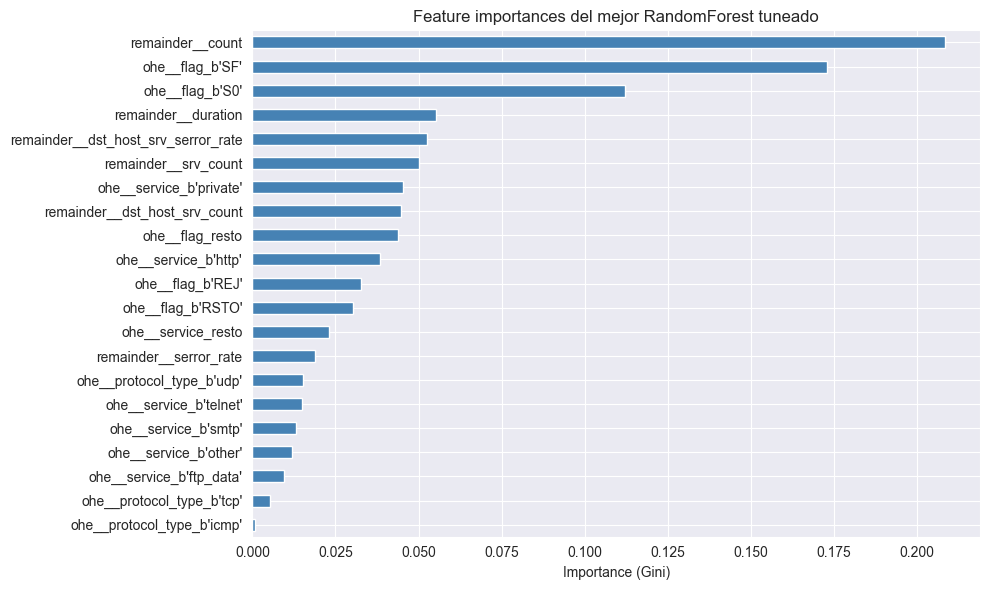

Top-5 features más importantes:
remainder__count                       0.209
ohe__flag_b'SF'                        0.173
ohe__flag_b'S0'                        0.112
remainder__duration                    0.055
remainder__dst_host_srv_serror_rate    0.053


In [27]:
# === Classification report en train y test ===
print('=== Classification report (train) ===')
print(classification_report(y_train, y_train_pred))

print('=== Classification report (test) ===')
print(classification_report(y_test, y_test_pred))

# === Feature importances del mejor estimador ===
best_rf = grid_model.best_estimator_.named_steps['model']
feature_names = grid_model.best_estimator_.named_steps['col_transformer'].get_feature_names_out()
importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature importances del mejor RandomForest tuneado')
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print('Top-5 features más importantes:')
print(importances.sort_values(ascending=False).head(5).round(3).to_string())


**Lectura del recorrido completo**

| Bloque | Cambio | Acc media | F1 (lectura) |
|---|---|---|---|
| Modelos 1 | solo numéricas | 0.70–0.84 | Perceptron muy bajo, le falta la señal de las categóricas |
| Modelos 2 | + OHE categóricas (`drop`) | ~0.88 | Perceptron sube al ver solo binarias |
| Modelos 3 | + `passthrough` numéricas | 0.90–0.93 | salto grande, es la opción correcta |
| Modelos 4 | + PCA (sin escalar) | 0.86–0.92 | bajada porque PCA está mal aplicado |
| Modelos 5 | RFC con train/test split | acc_test=0.881 | brecha train-test ~8 pts |
| Modelos 6 | RFC + GridSearchCV | acc_test=0.881 (igual) | el grid sube *train* pero no *test* |

- **1 - 2**: meter las categóricas con OHE en el pipeline sube todos los algoritmos. El que más se beneficia es el Perceptron: lo que le faltaba en Modelos 1 era la información de las categóricas, no era un tema de escalas (las numéricas ya estaban en [0, 1]).
- **2 - 3**: el cambio más relevante de todo el ejercicio. `remainder='passthrough'` deja entrar las 6 numéricas en el pipeline. Confirma que `remainder` no es un detalle: cambia qué información llega al algoritmo.
- **3 - 4**: PCA empeora respecto a Modelos 3.  El motivo no es tanto las escalas brutas (las numéricas ya están en [0, 1]), sino que tras el OHE mezclamos columnas binarias dispersas con continuas, y eso le hace ruido al PCA. En la celda paralela se ve que metiendo un `StandardScaler` entre el OHE y el PCA mejora 1–3 puntos en todos los algoritmos. Aun así, en este dataset de pocas *features* no hay tanto margen para reducir dimensionalidad; el valor de PCA es mayor en datasets de cientos de *features*.
- **4 - 5**: salimos de PCA, separamos en train/test, el test sale 0.881. La brecha train-test (~8 pts) sugiere *overfitting*.
- **5 - 6**: el `GridSearchCV` sube `acc_train` de 0.9643 a 0.9762 pero el `acc_test` se queda exactamente igual (0.8810). El tuneado le permite al modelo memorizar mejor el train sin traducirlo en mejor generalización. La brecha crece de ~8 a ~10 pts, señal todavía más clara de *overfitting*. La validación cruzada teóricamente ayuda con el *overfitting*, pero *no siempre*, sobre todo con algoritmos de tipo árbol, y aquí es justo lo que pasa.

**¿Qué haría a continuación?**

- Probar `class_weight='balanced'` en RFC para mitigar el desbalance, y comparar F1.
- Cambiar `KFold` por `StratifiedKFold` en el grid (el enunciado pide `KFold`, pero con desbalance lo correcto es estratificar).
- Mirar SHAP a nivel global (`shap.TreeExplainer` sobre el `best_estimator_`) y a nivel local (un par de registros mal clasificados del test).
- Para producción, considerar un modelo más simple si la brecha train-test no se cierra: a veces una `LogisticRegression` con `class_weight='balanced'` tiene F1 comparable y generaliza mejor.
